# **1.)Importing Dependencies**

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


In [2]:
# Data Analysis and Manipulation
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import StandardScaler,MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction.text import CountVectorizer

# Train-Test Split & Hyperparameter Tuning
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from scipy.stats import loguniform

# Models
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC, SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    AdaBoostClassifier,
    BaggingClassifier,
    GradientBoostingClassifier,
    VotingClassifier,
    StackingClassifier
)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix,precision_score,recall_score,f1_score

# Warnings
import warnings
warnings.filterwarnings('ignore')

In [3]:
#Data Loading
df1=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
df2=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
sample_sub = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")


In [4]:
#BaseLine Model
# Dummy feature
X_train = [[0]] * len(df1)
y_train = df1['label']
X_test = [[0]] * len(df2)

# Train dummy classifier
dummy_model = DummyClassifier(strategy="most_frequent")
dummy_model.fit(X_train, y_train)

# Predict
predictions = dummy_model.predict(X_test)

# submission
sample_sub['label'] = predictions
sample_sub.to_csv("submission.csv", index=False)

print("Submission created successfully!")
print("Majority class predicted:", df1['label'].mode()[0])


Submission created successfully!
Majority class predicted: 0


# **2.)Exploratory Data Analysis**

In [5]:
#Analyzing the Training Dataset
df1.head()

,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [6]:
#column 'label' is our target variable hence we must drop it and assign it to
#a different variable
X,y=df1.drop('label',axis=1),df1['label']

In [7]:
#shape of dataset
print(f"Shape of the Training Dataset is : {X.shape}")
print(f'Number of Rows : {X.shape[0]}')
print(f'Number of Features : {X.shape[1]}')

Shape of the Training Dataset is : (198000, 14)
Number of Rows : 198000
Number of Features : 14


In [8]:
#descriptive statistics of numerical columns in the training dataset
X.describe().T

,count,mean,std,min,25%,50%,75%,max
post_id,198000.0,68.447429,27.948390,20.0,39.0,72.0,72.0,129.0
emoticon_1,198000.0,0.279768,1.023234,0.0,0.0,0.0,0.0,47.0
emoticon_2,198000.0,0.048338,0.258477,0.0,0.0,0.0,0.0,11.0
emoticon_3,198000.0,0.121071,0.481013,0.0,0.0,0.0,0.0,17.0
upvote,198000.0,2.607975,5.054763,0.0,0.0,1.0,3.0,201.0
downvote,198000.0,0.666394,2.044335,0.0,0.0,0.0,1.0,107.0
if_1,198000.0,1.906152,25.635752,0.0,0.0,0.0,4.0,1860.0
if_2,198000.0,7.956212,14.839464,3.0,4.0,6.0,10.0,1833.0


In [9]:
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 19.8+ MB


In [10]:
#converting the created_date feature to datetime object to extract features
X['created_date']=pd.to_datetime(X['created_date'])

In [11]:
#datatypes of various columns in the training dataset
X.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype              
---  ------        --------------   -----              
 0   created_date  198000 non-null  datetime64[ns, UTC]
 1   post_id       198000 non-null  int64              
 2   emoticon_1    198000 non-null  int64              
 3   emoticon_2    198000 non-null  int64              
 4   emoticon_3    198000 non-null  int64              
 5   upvote        198000 non-null  int64              
 6   downvote      198000 non-null  int64              
 7   if_1          198000 non-null  int64              
 8   if_2          198000 non-null  int64              
 9   race          52577 non-null   object             
 10  religion      52577 non-null   object             
 11  gender        52577 non-null   object             
 12  disability    198000 non-null  bool               
 13  comment       197999 non-null  object       

In [12]:
#defining numerical and categorical features 
num_cols=X.select_dtypes(include=['int64'])
cat_cols=X.select_dtypes(include=['object','bool'])

print(f'numerical features are : {num_cols.columns.to_list()}')

print('---------------------------------------------------------------------------------------------------')

print(f'categorical features are : {cat_cols.columns.to_list()}')

numerical features are : ['post_id', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'upvote', 'downvote', 'if_1', 'if_2']
---------------------------------------------------------------------------------------------------
categorical features are : ['race', 'religion', 'gender', 'disability', 'comment']


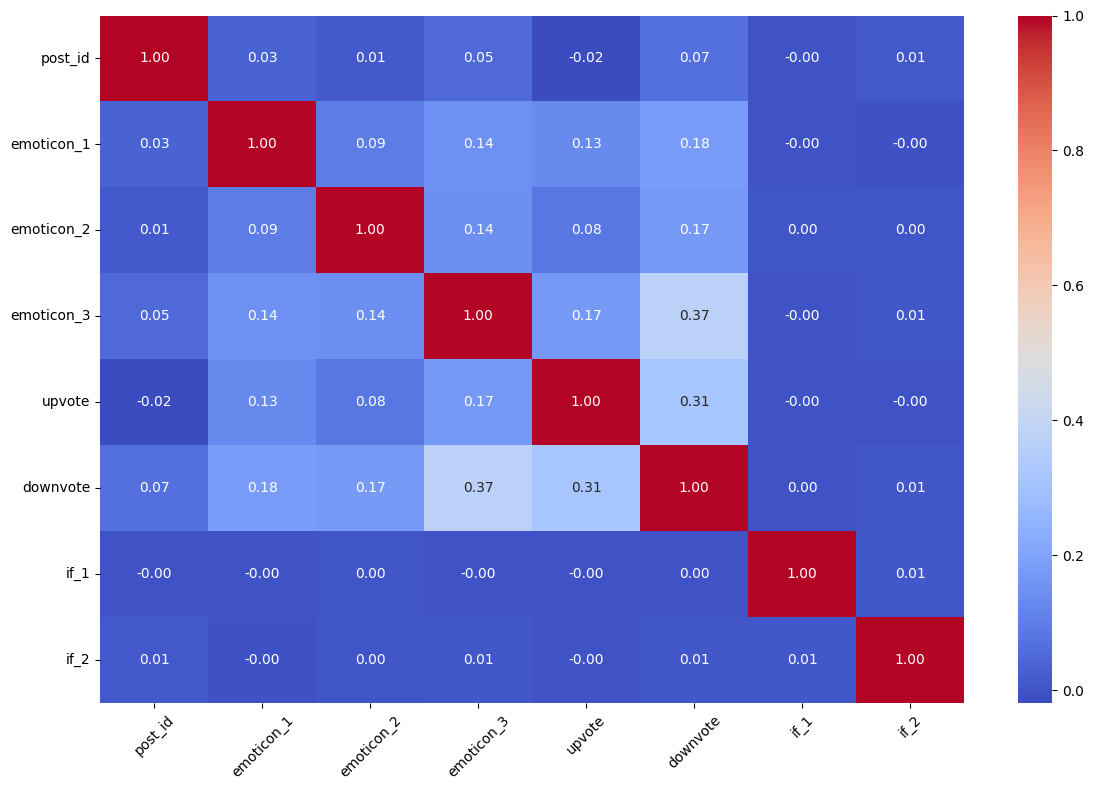

In [13]:
#correlation between numerical features
correlation=num_cols.corr()

plt.figure(figsize=(12,8)) 
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="coolwarm")
plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

**INFERENCE**

1. *Highest Positive Correlation occurs between **emoticon_3** and **downvote** features which is **0.37***

   * High correlation between **emoticon_3** and **downvote** implies that the set of emoticons in  emoticon_3 are being used in negative comments since they create large downvotes among users.
  
   * To reaffirm this assumption we can look at the correlation between (**downvote** and **emoticon_1**) which is **0.18** and (**downvote** and **emoticon_2**) which is **0.17** which implies that the emoticons in **emoticon_2** and **emoticon_1** have considerably less emoticons that generate negative reactions.
   

In [14]:
#Duplicate Check 
print(f'Duplicates present in the training set : {X.duplicated().sum()}')

Duplicates present in the training set : 0


In [15]:
#Checking Missing Values

print(X.isna().sum().sort_values(ascending=False))

print('---------------------------------')

print(f"Total Missing values are : {X.isna().sum().sum()}")

religion        145423
race            145423
gender          145423
comment              1
created_date         0
post_id              0
upvote               0
emoticon_3           0
emoticon_2           0
emoticon_1           0
if_2                 0
if_1                 0
downvote             0
disability           0
dtype: int64
---------------------------------
Total Missing values are : 436270


In [16]:
#Check for unique values for gender,race and religion features since they 
#collectively account for 436269 missing values.
a=X['gender'].unique()
b=X['race'].unique()
c=X['religion'].unique()
a,b,c

(array([nan, 'none', 'male', 'female', 'transgender', 'other'],
       dtype=object),
 array([nan, 'none', 'white', 'other', 'asian', 'black', 'latino'],
       dtype=object),
 array([nan, 'christian', 'muslim', 'none', 'jewish', 'atheist', 'other',
        'hindu', 'buddhist'], dtype=object))

In [17]:
#Handling Missing Values
#missing values for these features have been imputed with 'none' since imputation
#with mode values would be misleading.
cols = ['gender', 'race', 'religion']
X[cols] = X[cols].fillna('none')
X['comment']=df1['comment'].fillna('')

In [18]:
#cross-checking missing values after imputation
print(X.isna().sum().sort_values(ascending=False))

print('----------------------------')

print(f"Total Missing values are : {X.isna().sum().sum()}")

created_date    0
post_id         0
emoticon_1      0
emoticon_2      0
emoticon_3      0
upvote          0
downvote        0
if_1            0
if_2            0
race            0
religion        0
gender          0
disability      0
comment         0
dtype: int64
----------------------------
Total Missing values are : 0


**436270** *Missing Values have been Handled*

label
0    0.576631
2    0.315354
1    0.080394
3    0.027621
Name: proportion, dtype: float64
---------------------------------


<Axes: xlabel='label', ylabel='Count'>

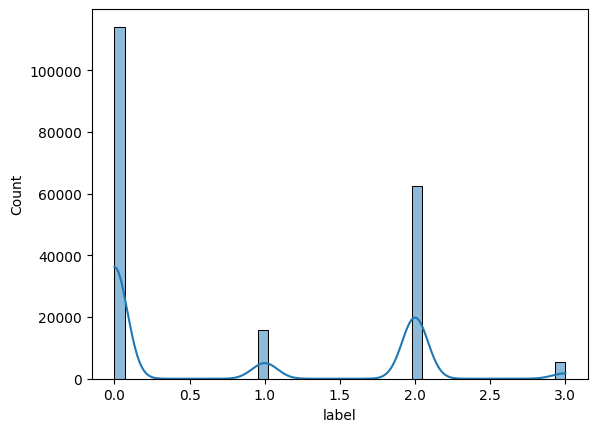

In [19]:
#Check to see if the target variables balanced 
print(y.value_counts(normalize=True))
print('---------------------------------')
sns.histplot(y,kde=True)

**INFERENCE**
* The label feature ,ie, our target variable is dominated by labels **0** and **2** accounting for almost **89%** of the total values in that feature.

In [20]:
categorical_cols=cat_cols.columns.to_list()
for i in range(len(categorical_cols)-1):
        print(X[categorical_cols[i]].value_counts(normalize=True))
        print('---------------------------------')


race
none      0.934874
white     0.027707
black     0.019540
other     0.008354
asian     0.006379
latino    0.003146
Name: proportion, dtype: float64
---------------------------------
religion
none         0.927636
christian    0.036318
muslim       0.024899
jewish       0.006283
other        0.002763
atheist      0.001106
buddhist     0.000505
hindu        0.000490
Name: proportion, dtype: float64
---------------------------------
gender
none           0.917091
female         0.040591
male           0.038126
transgender    0.003141
other          0.001051
Name: proportion, dtype: float64
---------------------------------
disability
False    0.986146
True     0.013854
Name: proportion, dtype: float64
---------------------------------


**INFERENCE**
1. On an average there are **93%** 'none' values across all categorical variables.
2. If we take a look at the disability feature **98.6%** False values imply that there are
very less comments on ability-related topics.
3. **Comment** feature has been excluded beacuse of the fact that all values in that feature would be unique hence value_counts would not make sense.

In [21]:
numerical_cols=num_cols.columns.to_list()
for i in range (1,len(numerical_cols)-2):
    print(X[numerical_cols[i]].value_counts(normalize=True))
    print('---------------------------------')

emoticon_1
0     0.853929
1     0.089308
2     0.029288
3     0.011929
4     0.006278
5     0.003222
6     0.001889
7     0.001136
8     0.000818
9     0.000515
10    0.000348
11    0.000343
12    0.000202
13    0.000136
15    0.000101
16    0.000101
14    0.000096
19    0.000066
17    0.000045
23    0.000035
22    0.000030
20    0.000025
18    0.000025
36    0.000020
25    0.000020
27    0.000015
24    0.000010
21    0.000010
31    0.000010
30    0.000010
32    0.000010
28    0.000005
46    0.000005
33    0.000005
47    0.000005
39    0.000005
Name: proportion, dtype: float64
---------------------------------
emoticon_2
0     0.959045
1     0.035510
2     0.004152
3     0.000894
4     0.000242
5     0.000106
6     0.000035
8     0.000005
11    0.000005
7     0.000005
Name: proportion, dtype: float64
---------------------------------
emoticon_3
0     0.913308
1     0.065742
2     0.014025
3     0.003859
4     0.001561
5     0.000667
6     0.000399
7     0.000207
8     0.000071
10    0.

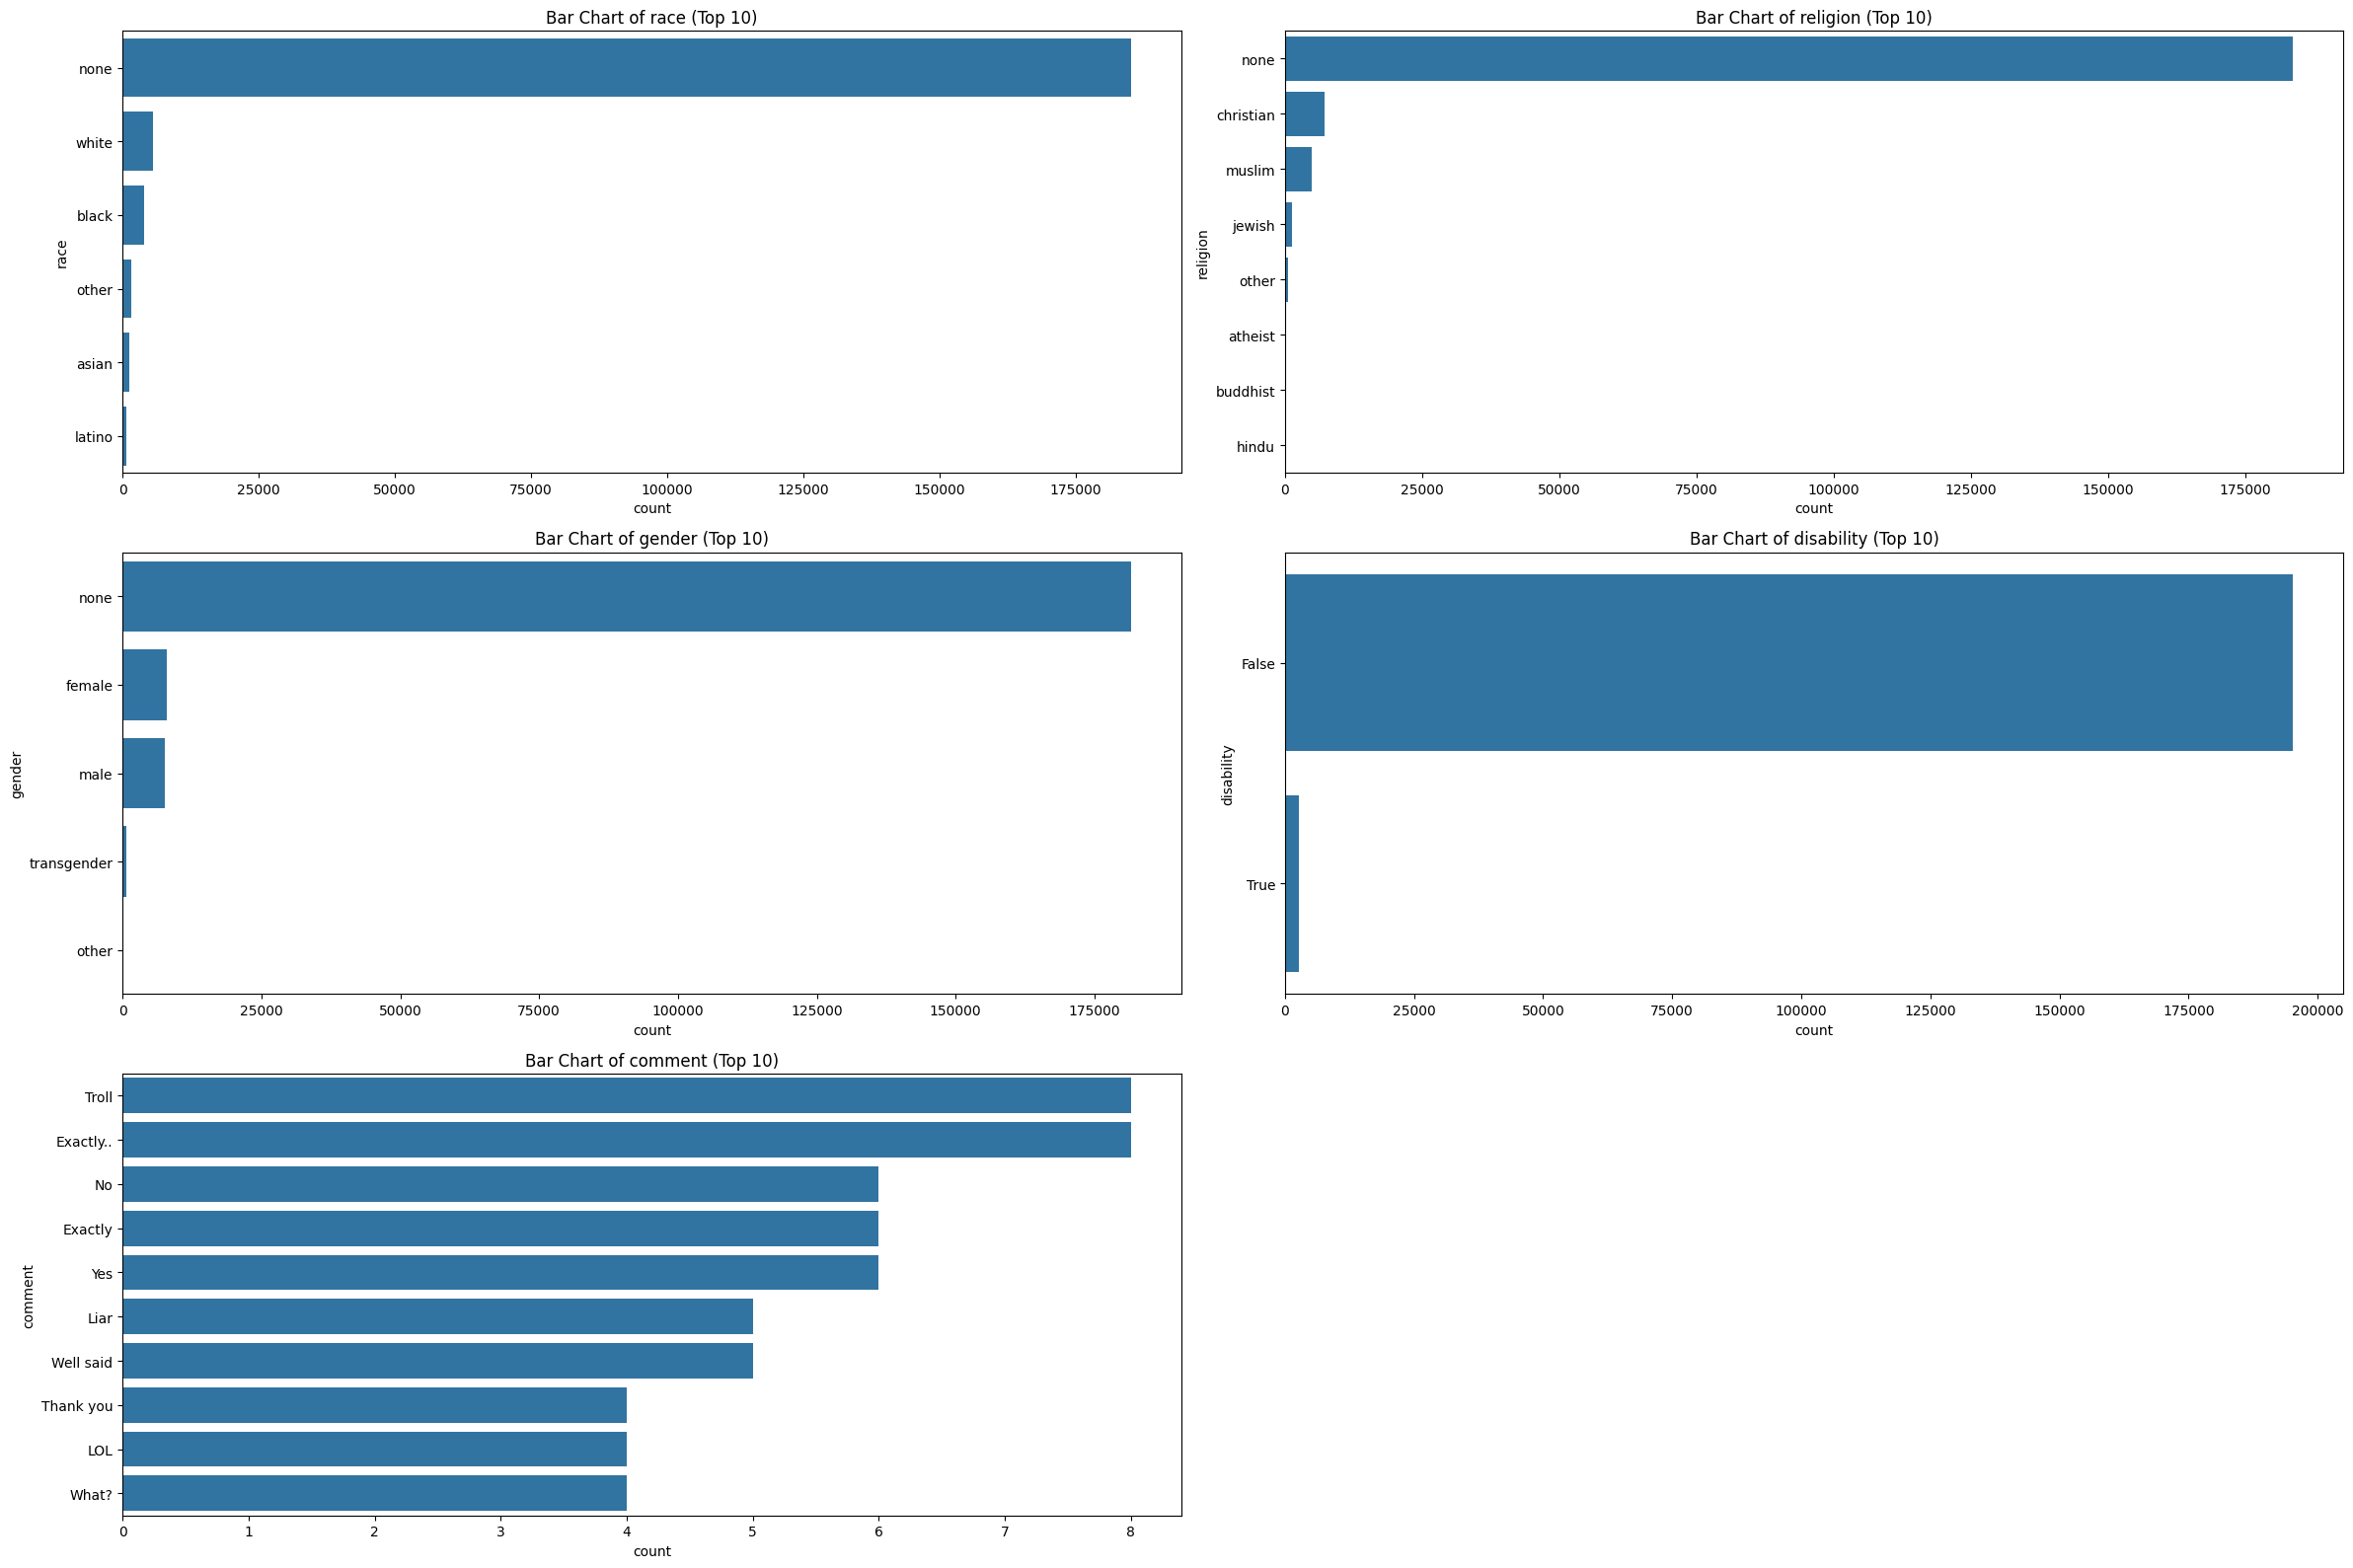

In [22]:
#Plotting countplots for categorical variables
#categorical features are : ['race', 'religion', 'gender', 'disability', 'comment']
plt.figure(figsize=(24,16))
for i, col in enumerate(cat_cols):
  plt.subplot(3,2,i+1)
  top_categories=X[col].value_counts().nlargest(10).index
  sns.countplot(data=X[X[col].isin(top_categories)],y=col,order=top_categories)
  plt.title(f"Bar Chart of {col} (Top 10)")
plt.tight_layout()
plt.show()


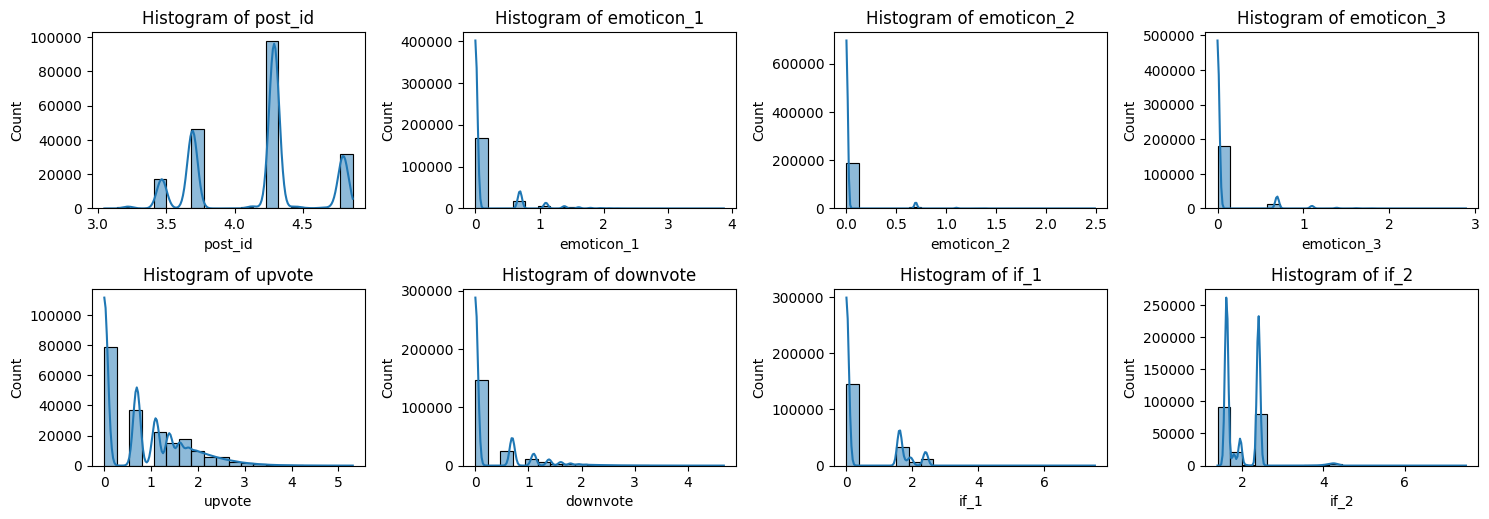

In [23]:
#Plotting histograms for numerical variables

plt.figure(figsize=(15,10))
for i, col in enumerate(num_cols):
    plt.subplot(4,4,i+1)
    sns.histplot(np.log1p(X[col]), bins=20, kde=True)
    plt.title(f"Histogram of {col}")
plt.tight_layout()
plt.show()

**INFERENCE**
1. There is a high spike at 0 in all emoticon gropus which indicates that most people are not using emoticons in their comments.
2. similarly higher proportions of comments are neither upvoted nor downvoted.

In [24]:
#Check for outliers using the IQR method
outliers_info = {}

for col in num_cols:
    q1 = X[col].quantile(0.25)
    q3 = X[col].quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    # filter outliers using the same dataframe conditioned on the IQR condition
    outliers = X[
        (X[col] < lower_bound) |
        (X[col] > upper_bound)
    ]

    outliers_info[col] = {
        'count': len(outliers),
        'indices': outliers.index.tolist()
    }
    print(f"{col}: {outliers_info[col]['count']}")


post_id: 4823
emoticon_1: 28922
emoticon_2: 8109
emoticon_3: 17165
upvote: 17304
downvote: 15173
if_1: 85
if_2: 3930


Saved plot


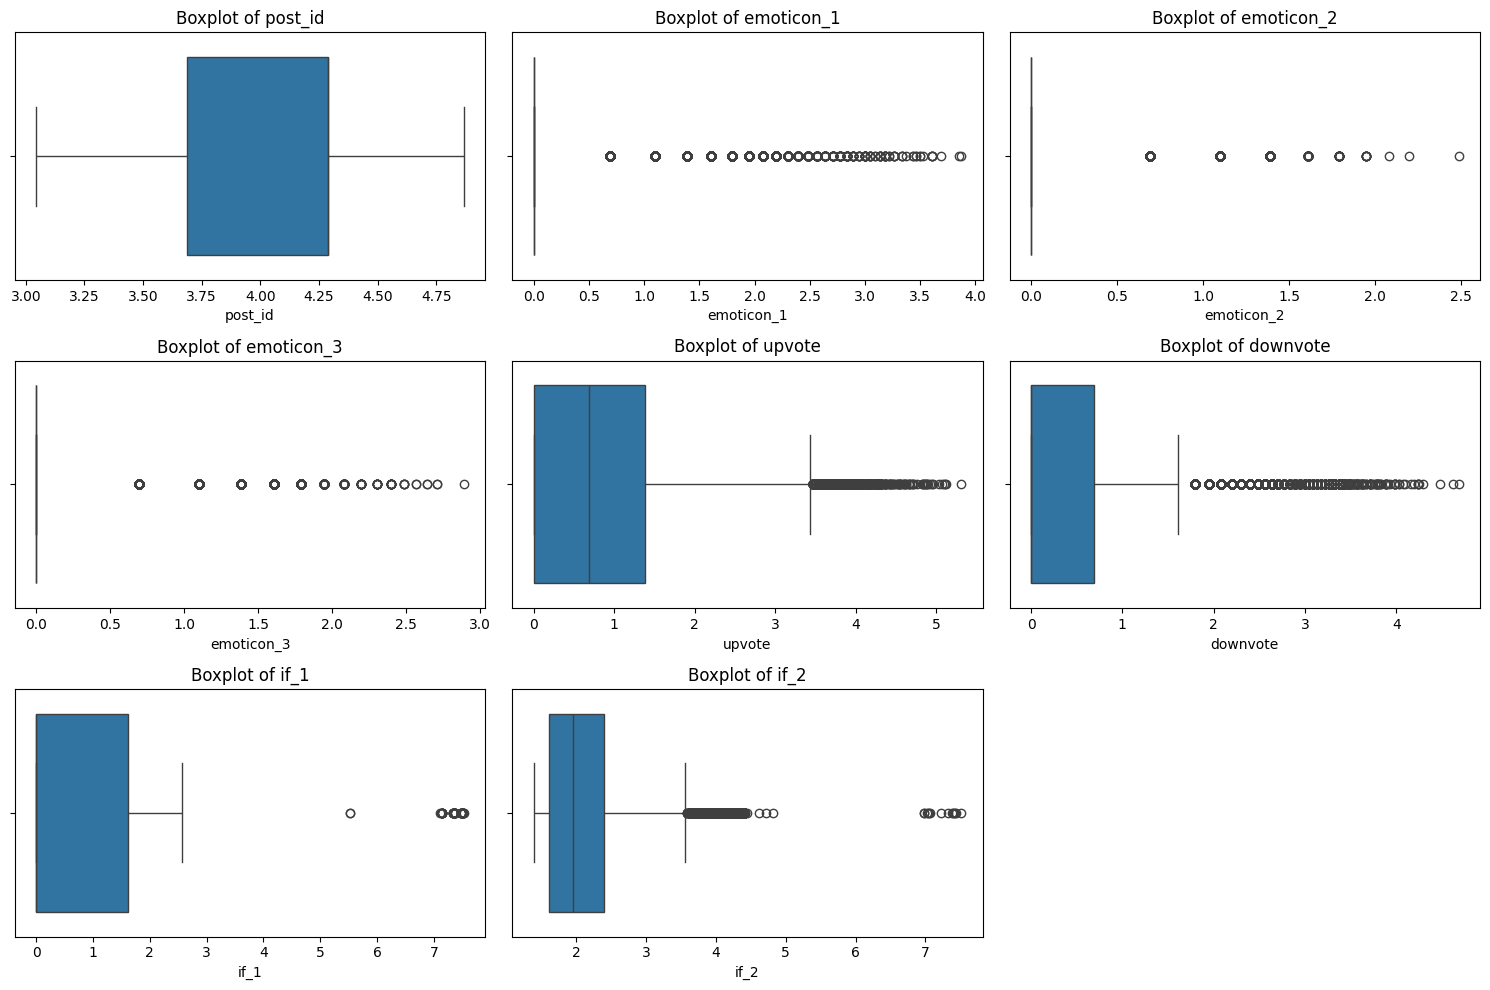

In [25]:
plt.figure(figsize=(15,10))

for i, col in enumerate(num_cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=np.log1p(X[col]))  
    plt.title(f"Boxplot of {col}")

plt.tight_layout()
plt.savefig("Numerical_features_boxplot.png")
print("Saved plot")

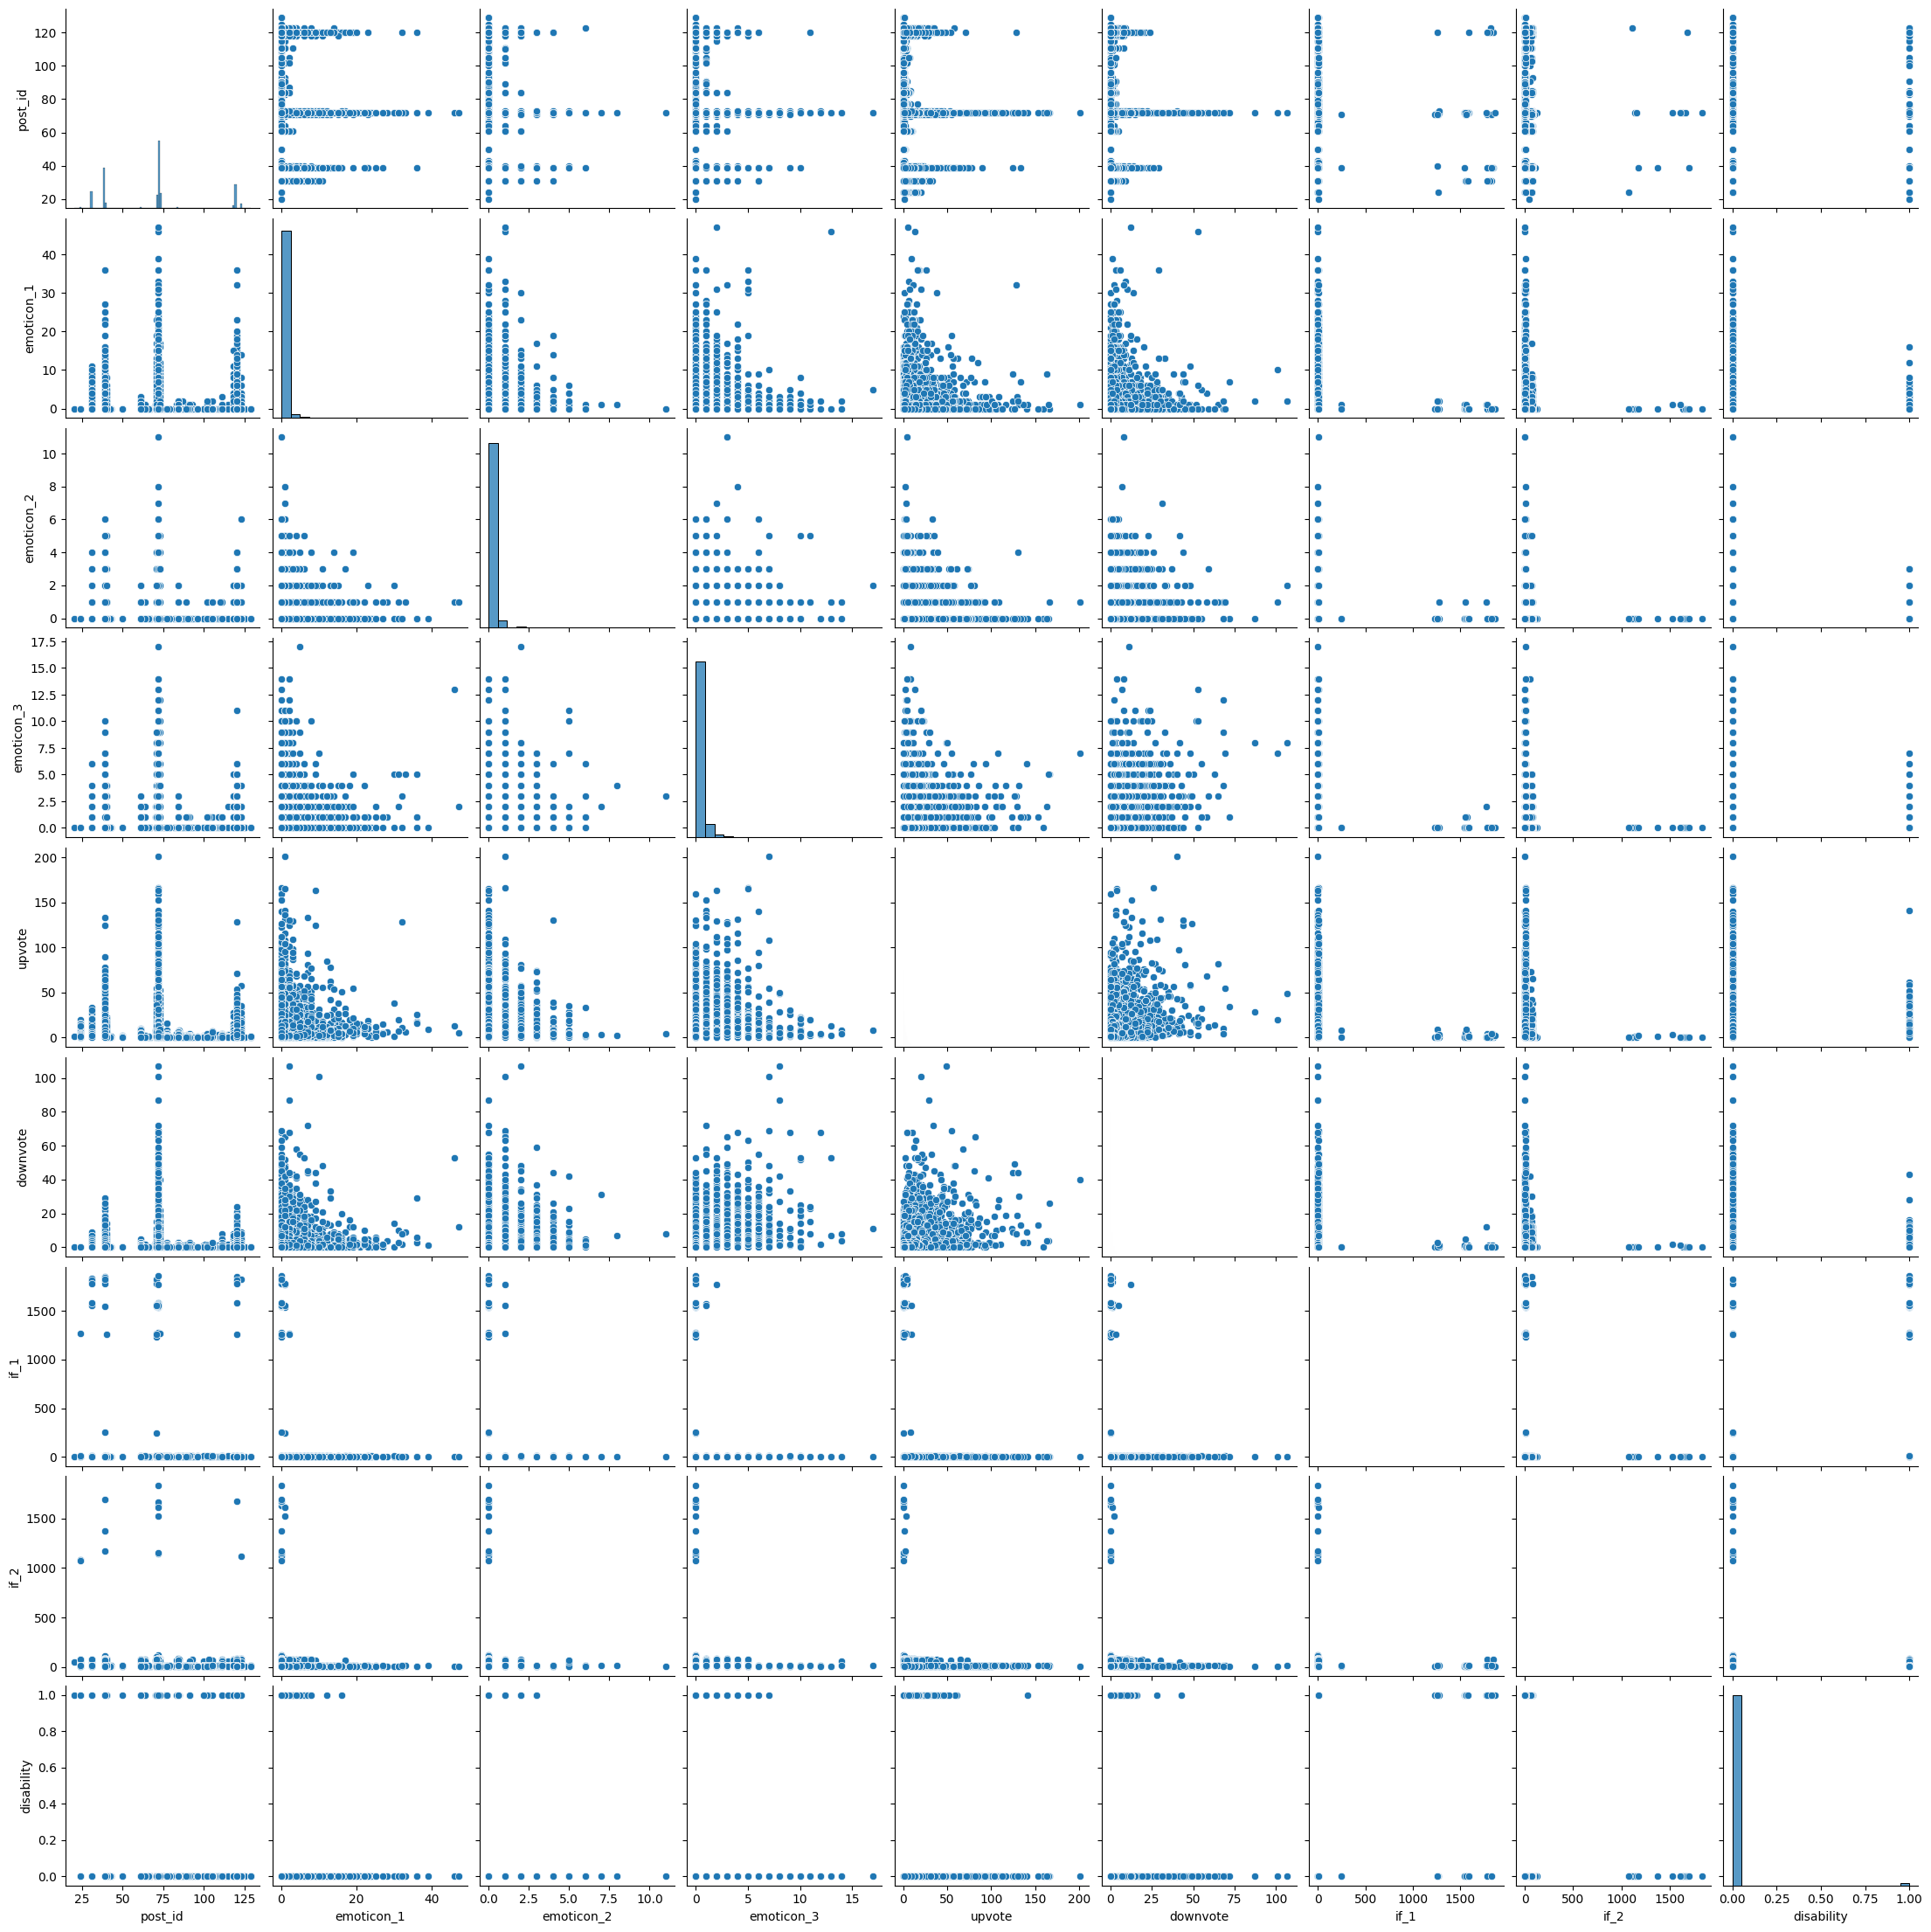

In [26]:
#Multivariate Analysis of Features
sns.pairplot(X)

# **3.)PreProcessing and Feature Engineering**

**1.)Regex Cleaning of the Comment Feature**


In [27]:
import re

def clean_text(text):
  text=str(text).lower() #converting all text into lowercase
  text=re.sub(r'<.*?>',"",text) #removing html tags
  text=re.sub(r'http\S+',"",text) #removing links(if present)
  text=re.sub(r'\S+@\S+',"",text) #removing email ids
  text=re.sub(r'\d+',"",text) #removing numbers present in the comments,since they can mislead predictions.  
  text=re.sub(r'[^a-zA-Z\s]',"",text) #removing special characters,punctuations
  text=re.sub(r"\s+"," ",text).strip()#removes extra spaces
  return text

text_column='comment'
X['cleaned_comment']=X[text_column].apply(clean_text)
X[['cleaned_comment',text_column]]
X=X.drop(columns=['comment'])

In [28]:
#converting disability feature into numerical values, True-->1 and False-->0
X['disability']=X['disability'].astype(int)

In [29]:
#Extracting appropriate features from the created_date feature

X['year']=X['created_date'].dt.year
X['month']=X['created_date'].dt.month
X['day']=X['created_date'].dt.day
X['DayOfWeek']=X['created_date'].dt.dayofweek
X['Weekend']=X['created_date'].dt.dayofweek.isin([5,6]).astype(int)
X['Hour_of_Day']=X['created_date'].dt.hour

X=X.drop(columns=['created_date'])

In [30]:
#checking if created_date column is dropped and new features are added
X.head()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,cleaned_comment,year,month,day,DayOfWeek,Weekend,Hour_of_Day
0,73,0,0,0,0,1,0,10,none,none,none,0,she might be a bright spot for a party keou on...,2024,1,18,3,0,8
1,39,0,0,0,6,0,0,4,none,none,none,0,under alaska law a nontribal member is not bou...,2024,3,24,6,1,21
2,31,0,1,1,0,0,0,10,none,none,none,0,in the future please spare me your strawman dr...,2024,4,24,2,0,20
3,39,0,0,0,5,0,0,10,none,none,none,0,ps that should have been rot instead of corrup...,2023,5,28,6,1,22
4,39,0,0,0,0,0,0,10,none,none,none,0,today the confederate flagtomorrow the nazi fl...,2023,9,9,5,1,23


In [31]:
#defining the respective numerical and categorical columns
numerical_features=X.select_dtypes(include=np.number).columns.to_list()
categorical_features=X.select_dtypes(include=['object']).columns.to_list()
cat_features=[col for col in categorical_features if col!='cleaned_comment']
text_features=['cleaned_comment']

In [32]:
#PreProcessing Pipeline

#Numerical Pipeline
numerical_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='median')),
    #('scaler',MinMaxScaler())
    ('scaler',StandardScaler())
    
])

#Categorical Pipeline
categorical_pipeline=Pipeline(steps=[
    ('imputer',SimpleImputer(strategy='most_frequent')),
    ('encoder',OneHotEncoder(handle_unknown='ignore'))
    
])

#Text Pipeline
text_pipeline=Pipeline(steps=[
    ('tfidf',TfidfVectorizer(
        stop_words='english',
        max_features=13000,
        ngram_range=(1,1),
        sublinear_tf=True,
        lowercase=True,
        min_df=2,
        max_df=0.83
    ))
])

In [33]:
preprocessor=ColumnTransformer(
    transformers=[
        ('text',text_pipeline,'cleaned_comment'),
        ('num',numerical_pipeline,numerical_features),
        ('cat',categorical_pipeline,categorical_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('text',
                                 Pipeline(steps=[('tfidf',
                                                  TfidfVectorizer(max_df=0.83,
                                                                  max_features=13000,
                                                                  min_df=2,
                                                                  stop_words='english',
                                                                  sublinear_tf=True))]),
                                 'cleaned_comment'),
                                ('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['post_id', 'emoticon_1', 'emoticon_2',
                                  'emoticon_3', 'upvote', 'downvote', 'if_1',
                                  'if_2', 'disability', 'year', 'month', 'day',
                                  'DayOfWeek', 'Weekend', 'Hour_of_Day']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['race', 'religion', 'gender',
                                  'cleaned_comment'])])

# **4.)Train-Test-Split**

In [34]:
#Splitting the training Dataset into 80% training and 20% validations sets
X_train,X_val,y_train,y_val=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

X_train.shape,X_val.shape,y_train.shape,y_val.shape

((158400, 19), (39600, 19), (158400,), (39600,))

# **5.)Test Data Preprocessing**

In [35]:
#test data preprocessing

#making a copy of test data to avoid any errors
X_prime=df2.copy()

#converting the created_date feature to datetime onject to extract extra features
X_prime['created_date']=pd.to_datetime(X_prime['created_date'])

#extracting features
X_prime['year']=X_prime['created_date'].dt.year
X_prime['month']=X_prime['created_date'].dt.month
X_prime['day']=X_prime['created_date'].dt.day
X_prime['DayOfWeek']=X_prime['created_date'].dt.dayofweek
X_prime['Weekend']=X_prime['created_date'].dt.dayofweek.isin([5,6]).astype(int)
X_prime['Hour_of_Day']=X_prime['created_date'].dt.hour

#dropping the created_date datetime features after extraction
X_prime=X_prime.drop(columns=['created_date'])

#converting the disability feature containing boolean values True and False into a numerical feature
#mapping True-->1 and False-->0
X_prime['disability']=X_prime['disability'].astype(int)

#Text cleaning

def clean_text(text):
  text=str(text).lower() #converting all text into lowercase
  text=re.sub(r'<.*?>',"",text) #removing html tags
  text=re.sub(r'http\S+',"",text) #removing links(if present)
  text=re.sub(r'\S+@\S+',"",text) #removing email ids
  text=re.sub(r'\d+',"",text) #removing numbers present in the comments,since they can mislead predictions.  
  text=re.sub(r'[^a-zA-Z\s]',"",text) #removing special characters
  text=re.sub(r"\s+"," ",text).strip()
  return text

text_column='comment'
X_prime['cleaned_comment']=X_prime[text_column].apply(clean_text)
X_prime=X_prime.drop(columns=['comment'])

In [36]:
X_prime.head()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,year,month,day,DayOfWeek,Weekend,Hour_of_Day,cleaned_comment
0,72,2,0,0,4,1,0,10,NaN,NaN,NaN,0,2024,2,8,3,0,13,canada is being run by someone with the mental...
1,123,0,0,0,0,0,0,10,NaN,NaN,NaN,0,2024,3,1,4,0,23,and your comment is leftwing drivel
2,120,0,0,0,3,0,0,4,NaN,NaN,NaN,0,2024,2,9,4,0,21,
3,123,0,0,0,0,0,0,4,NaN,NaN,NaN,0,2024,2,17,5,1,3,trump jl blames the secret service james comey...
4,123,0,0,0,0,0,0,11,NaN,NaN,NaN,0,2024,4,24,2,0,2,it was hard enough to get the stench out of th...


# **6.)Model Building**

**1.)LOGISTIC REGRESSION**


In [37]:
log_reg=LogisticRegression(
    max_iter=1000,
    class_weight='balanced',
    random_state=42,
)

model_log=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',log_reg)
    ]
)

#Training the model
model_log.fit(X_train,y_train)

y_pred=model_log.predict(X_val)

#Model evaluation
#F-1 Score
acc_logreg=accuracy_score(y_val,y_pred)
f1_logreg=f1_score(y_val,y_pred,average="macro")
print(f'Accuracy : {acc_logreg}') #we always use(true_val,pred_val)
print(f'F1-Macro : {f1_logreg}')
print(classification_report(y_val,y_pred))

# Accuracy : 0.9042171717171718
# F1-Macro : 0.8057179070095764

Accuracy : 0.9042171717171718
F1-Macro : 0.8057179070095764
              precision    recall  f1-score   support

           0       0.98      0.93      0.96     22835
           1       0.70      0.83      0.76      3183
           2       0.87      0.89      0.88     12488
           3       0.57      0.70      0.63      1094

    accuracy                           0.90     39600
   macro avg       0.78      0.84      0.81     39600
weighted avg       0.91      0.90      0.91     39600



**2.)Linear SVC**

In [38]:
# model_svc_lin=Pipeline(steps=[
#     ('preprocessor',preprocessor),
#     ('model',LinearSVC(class_weight='balanced'))
# ])
# model_svc_lin.fit(X_train,y_train)
# y_pred=model_svc_lin.predict(X_val)

# # Model evaluation
# # F-1 Score

# acc_lsvc=accuracy_score(y_val,y_pred)
# f1_lsvc=f1_score(y_val,y_pred,average="macro")
# print(f'Accuracy : {acc_lsvc}') #we always use(true_val,pred_val)
# print(f'F1-Macro : {f1_lsvc}')
# print(classification_report(y_val,y_pred))

# Accuracy : 0.8075505050505051
# F1-Macro : 0.6979620768652093

**3.)Random Forest**

In [39]:
# rf= RandomForestClassifier(
#     n_estimators=100,
#     max_depth=10,              
#     n_jobs=-1,                 
#     class_weight='balanced',   
#     random_state=42
# )

# model_rf=Pipeline(
#     steps=[
#         ('preprocessor',preprocessor),
#         ('model',rf)
#     ]
# )
# model_rf.fit(X_train,y_train)
# y_pred=model_rf.predict(X_val)

# # Model evaluation
# # F-1 Score

# acc_rf=accuracy_score(y_val,y_pred)
# f1_rf=f1_score(y_val,y_pred,average="macro")
# print(f'Accuracy : {acc_rf}') #we always use(true_val,pred_val)
# print(f'F1-Macro : {f1_rf}')
# print(classification_report(y_val,y_pred))

# Accuracy : 0.6928030303030303
# F1-Macro : 0.5683572347079391

**4.)SGDClassifier**

In [40]:
# sgd=SGDClassifier(
#     loss='log_loss',           
#     class_weight='balanced',
#     max_iter=1000,
#     random_state=42
# )
# model_sgd=Pipeline(steps=[
#     ('preprocessor',preprocessor),
#     ('model',sgd)
# ])

# model_sgd.fit(X_train,y_train)
# y_pred=model_sgd.predict(X_val)

# # Model evaluation
# # F-1 Score

# acc_sgd=accuracy_score(y_val,y_pred)
# f1_sgd=f1_score(y_val,y_pred,average="macro")
# print(f'Accuracy : {acc_sgd}') #we always use(true_val,pred_val)
# print(f'F1-Macro : {f1_sgd}')
# print(classification_report(y_val,y_pred))

# Accuracy : 0.886439393939394
# F1-Macro : 0.7670621195100144

**5.)Gradient Boosting**

In [41]:
# gb=GradientBoostingClassifier()
# model_gb=Pipeline(
#     steps=[
#         ('preprocessor',preprocessor),
#         ('model',gb)
#     ]
# )
# model_gb.fit(X_train,y_train)
# y_pred=model_gb.predict(X_val)

# # Model evaluation
# # F-1 Score

# acc_gb=accuracy_score(y_val,y_pred)
# f1_gb=f1_score(y_val,y_pred,average="macro")
# print(f'Accuracy : {acc_gb}') #we always use(true_val,pred_val)
# print(f'F1-Macro : {f1_gb}')
# print(classification_report(y_val,y_pred))

# Accuracy : 0.8967929292929293
# F1-Macro : 0.7443326840567609

**6.)XGBOOST**

In [42]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42
)
model_xgb=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',xgb)
])

model_xgb.fit(X_train,y_train)
y_pred=model_xgb.predict(X_val)

Model evaluation
F-1 Score

acc_xgb=accuracy_score(y_val,y_pred)
f1_xgb=f1_score(y_val,y_pred,average="macro")
print(f'Accuracy : {acc_xgb}') #we always use(true_val,pred_val)
print(f'F1-Macro : {f1_score(y_val,y_pred,average="macro")}')
print(classification_report(y_val,y_pred))

# Accuracy : 0.9057323232323232
# F1-Macro : 0.7689653886083119

SyntaxError: invalid syntax (3863553004.py, line 20)

**7.)LightGBM**

In [ ]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    class_weight='balanced',
    random_state=42
)
model_lgbm=Pipeline(steps=[
    ('preprocessor',preprocessor),
    ('model',lgbm)
])

model_lgbm.fit(X_train,y_train)
y_pred=model_lgbm.predict(X_val)

# Model evaluation
# F-1 Score

acc_lgbm=accuracy_score(y_val,y_pred)
f1_lgbm=f1_score(y_val,y_pred,average="macro")
print(f'Accuracy : {acc_lgbm}') #we always use(true_val,pred_val)
print(f'F1-Macro : {f1_lgbm}')
print(classification_report(y_val,y_pred))

# Accuracy : 0.8989646464646465
# F1-Macro : 0.7868827519334307

# **7.)Model Comparison**

In [ ]:
# models=[
#     'Logistic Rgeression',
#     'Linear SVC',
#     'Random Forest',
#     'SGDClassifier',
#     'Gradient Boosting',
#     'XGBoost',
#     'LightGBM'
# ]

# accuracy_scores=[
#     acc_logreg,
#     acc_lsvc,
#     acc_rf,
#     acc_sgd,
#     acc_gb,
#     acc_xgb,
#     acc_lgbm
# ]

# f1_scores=[
#     f1_logreg,
#     f1_lsvc,
#     f1_rf,
#     f1_sgd,
#     f1_gb,
#     f1_xgb,
#     f1_lgbm
# ]
# # #firstly we try a barplot b/w models and their accuracy scores
# # #second we make a pandas dataframe with two columns:Models and f1_scores and filter out top 3 best models

# model_comparison=pd.DataFrame({
#     'Models': models,
#     'F1-Macro Scores': f1_scores
# })

In [ ]:
# # #sorting values according to f1-score from highest to lowest
# model_comparison=model_comparison.sort_values(ascending=False,by='F1-Macro Scores')

# #picking top-3 models 
# model_comparison[:3]

# model_comparison.plot.bar(x='Models',y='F1-Macro Scores',title='Model Comparison',rot=90)

# plt.xlabel('Models')
# plt.ylabel('F1-Macro Scores')
# #plt.ylim(0,1)
# plt.show()


In [ ]:
# top_three_models=model_comparison[:3]
# top_three_models.plot.bar(x='Models',y='F1-Macro Scores',title='Top Three Models',rot=90)

# plt.xlabel('Models')
# plt.ylabel('F1-Macro Scores')
# #plt.ylim(0,1)
# plt.show()


# **8.)Hyper Parameter Tuning**

In [ ]:
# log_reg=LogisticRegression(random_state=42,
#                           max_iter=1000,
#                           class_weight='balanced')
   

# model_log=Pipeline(
#     steps=[
#         ('preprocessor',preprocessor),
#         ('model',log_reg)
#     ]
# )                            

# param_dist = {"model__C": loguniform(0.001,10),
#              "model__solver":['lbfgs','saga'],
#              'model__penalty':['l2']
#              }

# random_search = RandomizedSearchCV(
#     model_log,
#     param_distributions=param_dist,
#     n_iter=15,                
#     cv=3,
#     scoring="f1_macro",
#     n_jobs=-1,
#     random_state=42
# )


# random_search.fit(X_train, y_train)

# best_model = random_search.best_estimator_

# y_pred = best_model.predict(X_val)

# print(random_search.best_params_)
# print("F1-Macro:", f1_score(y_val, y_pred, average="macro"))

In [ ]:
# log_reg=LogisticRegression(random_state=42,
#                           max_iter=1000,
#                           class_weight='balanced')

# model_logr=Pipeline(steps=[
#     ('preprocessor',preprocessor),
#     ('model',log_reg)
# ])

# params_grid={"model__C":[0.3315,0.3320,0.3325],
#             'model__solver':['lbfgs'],
#             "model__penalty":['l2'],
#             "model__max_iter":[1000,2000]}

# grid = GridSearchCV(
#     model_logr,
#     param_grid=params_grid,
#     cv=3,
#     scoring="f1_macro",
#     n_jobs=-1
# )

# grid.fit(X_train,y_train)
# best_model = grid.best_estimator_

# y_pred = best_model.predict(X_val)

# print("Best Params:", grid.best_params_)
# print("F1-Macro:", f1_score(y_val, y_pred, average="macro"))
#Best Params: {'model__C': 0.332, 'model__max_iter': 1000, 'model__penalty': 'l2', 'model__solver': 'lbfgs'}
# F1-Macro: 0.7989518963568362

In [ ]:
log_reg=LogisticRegression(
    max_iter=1000,
    C=0.332,
    class_weight='balanced',
    solver='lbfgs',
    penalty='l2'
)

model_log=Pipeline(
    steps=[
        ('preprocessor',preprocessor),
        ('model',log_reg)
    ]
)
model_log.fit(X,y)
#y_pred=model_log.predict(X_prime)
probs = model_log.predict_proba(X_prime)
probs[:,0]*=1.003
probs[:,1]*=1.005
probs[:,2]*=1.003
probs[:, 3] *= 1.005
y_pred = np.argmax(probs, axis=1)


In [ ]:
df_sample = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/Sample.csv")

submission = pd.DataFrame({
    "ID": df_sample["ID"],
    "label": y_pred.astype(int)
})

submission.to_csv("submission.csv", index=False)

# **MILESTONES**

**MILESTONE-2**

In [ ]:
#MILESTONE-2
# train_df=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# test_df=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')
# train_df['created_date']=pd.to_datetime(train_df['created_date'])

In [ ]:
# train_df['month']=train_df['created_date'].dt.month
# train_df['month'].mode()

In [ ]:
# train_df['total_emoticons']=train_df['emoticon_1']+train_df['emoticon_2']+train_df['emoticon_3']
# train_df['total_emoticons'].max()

In [ ]:
# np.median(train_df.loc[train_df['label']==3, 'comment'].str.len().values)

In [ ]:
# train_df.loc[train_df['label'] == 1, 'comment'].str.split().str.len().mean()

In [ ]:
# count = train_df['comment'].str.contains('Trump', na=False).sum()
# count

**MILESTONE-5**

In [ ]:
# #PREPROCESSING STEPS AS PER MILESTONE-5

# #loading the datasets
# X_dot=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
# X_tst=pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

# #removing the label column
# X,y=X_dot.drop('label',axis=1),X_dot['label']

# #Step_1 : 1.)Datetime feature Engineering

# X['created_date']=pd.to_datetime(X['created_date'])
# X_tst['created_date']=pd.to_datetime(X_tst['created_date'])

# #2.) extracting year,month,hour from created_date feature

# X['year']=X['created_date'].dt.year
# X['month']=X['created_date'].dt.month
# X['hour']=X['created_date'].dt.hour

# X_tst['year']=X_tst['created_date'].dt.year
# X_tst['month']=X_tst['created_date'].dt.month
# X_tst['hour']=X_tst['created_date'].dt.hour

In [ ]:
# X=X.drop(columns=['created_date'])
# X_tst=X_tst.drop(columns=['created_date'])

In [ ]:
# #Step_2 : Handling Missing Values
# cols = ['gender', 'race', 'religion']

# X[cols] = X[cols].fillna('unknown')
# X['comment']=X['comment'].fillna('')

# X_tst[cols] = X_tst[cols].fillna('unknown')
# X_tst['comment']=X_tst['comment'].fillna('')


# X['disability']=X['disability'].astype(int)
# X_tst['disability']=X_tst['disability'].astype(int)

In [ ]:
# #Step_3 : 
# # Define column groups
# text_feature = "comment"
# categorical_features = ["race", "religion", "gender"]

# # ColumnTransformer
# preprocessor = ColumnTransformer(
#     transformers=[
#         ("text", TfidfVectorizer(stop_words="english", max_features=5000), text_feature),
#         ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
#     ],
#     remainder="passthrough"
# )

In [ ]:
# X_tr= preprocessor.fit_transform(X)
# X_test = preprocessor.transform(X_tst)

In [ ]:
# #Step_5
# X_train, X_val, y_train, y_val=train_test_split(X_tr,y,test_size=0.2,random_state=42)
# X_train.shape,X_val.shape,y_train.shape,y_val.shape

In [ ]:
# #Training the Multinomial Nive Bayes
# from sklearn.naive_bayes import MultinomialNB

# model_mnb=MultinomialNB()

# model_mnb.fit(X_train,y_train)

# y_pred=model_mnb.predict(X_val)

# print(f'Accuracy : {accuracy_score(y_val,y_pred)}')

# print(classification_report(y_val,y_pred))

In [ ]:
# #Training Logistic regression model 
# log_reg=LogisticRegression(
#     solver="liblinear",
#     max_iter=500,
#     random_state=42,
#     C=1
# )

# log_reg.fit(X_train,y_train)

# y_pred=log_reg.predict(X_train)

# print(f'Accuracy : {accuracy_score(y_train,y_pred)}')

# print(classification_report(y_train,y_pred))

In [ ]:
# log_reg = LogisticRegression(solver="liblinear",
#                              random_state=42, 
#                              max_iter=500)

# param_grid = {"C": [0.1, 1, 10]}

# grid = GridSearchCV(log_reg, param_grid, cv=3, scoring="accuracy", n_jobs=-1)

# grid.fit(X_train, y_train)

# best_model = grid.best_estimator_

# y_pred = best_model.predict(X_val)

# print(grid.best_params_)